# Phase 2: Layer 2 — Decision-Making Bias Analysis (RQ2)

**Project:** A Perception-Aware Framework for Evaluating Counterfactual Passing Options in Professional Football
**Author:** Raeesa Lorgat (2686242)

**Purpose of this notebook:** Layer 1 (see `setup_euro2024.ipynb`) established which teammates a player could realistically see at the moment of a pass, and answered RQ1 which was whether that visibility filter changes what counts as the "optimal" pass. This notebook builds Layer 2, which asks a different question: **among the teammates a player could see, how often did they bypass a genuinely better option?**

Answering that fairly requires narrowing "visible teammates" down to teammates who were also **legitimate** alternatives meaning not offside, and not unrealistically difficult to reach. This notebook adds those two filters before computing the forward-progressive bias rate specified in the proposal (Section 4.5.2):

1. **Offside detection** — using 360 freeze-frame defender positions, determine whether each candidate teammate was onside at the moment of the pass.
2. **xP (expected pass completion probability)** — weight candidates by how realistically executable the pass was, based on distance, angle, and defender proximity.
3. **Forward-progressive classification** — using Karun Singh's public xT grid, identify which remaining candidates represent a genuine forward-progressive improvement over the pass actually made.

**What this notebook reuses rather than recomputes:** the vision-cone classification logic (`src/vision_cone.py`), the trained VAEP models, and the RQ1 counterfactual results (`cf_valid`, `cf_valid_all3`) — all loaded from disk, not rebuilt from scratch.

**Environment:** same venv/kernel as `01_setup_euro2024.ipynb` (Python 3.11.2) — no new packages beyond `socceraction`'s `xthreat` module, already installed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import sys
sys.path.append('..')

from src.vision_cone import angle_to_teammate

import socceraction.xthreat as xthreat
xT_model = xthreat.load_model("https://karun.in/blog/data/open_xt_12x8_v1.json")

# reload everything already computed in notebook 1 — no need to recompute
cf_valid = pd.read_pickle('../data/results/rq1_counterfactual_comparison.pkl')
cf_valid_all3 = pd.read_pickle('../data/results/rq1_counterfactual_comparison_all3.pkl')

Offside detection using the 360 freeze frame

A candidate teammate is offside if they're closer to the opponent's goal line than both the ball and the second-deepest defender at that moment, the goalkeeper included in that ordering, not automatically excluded (in practice they're usually deepest, but not always).

To determine which end each team is defending, since raw StatsBomb coordinates don't self-adjust for attacking direction, this uses the opposing goalkeeper's position, already present in the same 360 freeze frame via the `keeper` flag. Wherever the opponent keeper stands tells us which end the passer's team is attacking toward, with no separate lookup needed.

In [3]:
from src.vision_cone import add_orientation_vectors, build_pass_visibility_table
from statsbombpy import sb

sample_match_id = "3943043"  # reuse the Euro 2024 final
m_events = sb.events(match_id=sample_match_id)
m_events_oriented = add_orientation_vectors(m_events)
m_frames = sb.frames(match_id=sample_match_id, fmt='dataframe')

sample_pass_events = m_events_oriented[
    (m_events_oriented['type'] == 'Pass') &
    (m_events_oriented['orientation_vector'].notna())
]
sample = sample_pass_events.iloc[50]
event_id = sample['id']

frame = m_frames[m_frames['id'] == event_id]
opponent_keeper = frame[(frame['teammate'] == False) & (frame['keeper'] == True)]

print(f"Opponent keeper found in this frame: {not opponent_keeper.empty}")
if not opponent_keeper.empty:
    print(f"Opponent keeper location: {opponent_keeper.iloc[0]['location']}")
print(f"Passer location: {sample['location']}")

Opponent keeper found in this frame: True
Opponent keeper location: [115.6168082840095, 43.25187666650353]
Passer location: [92.4, 23.2]


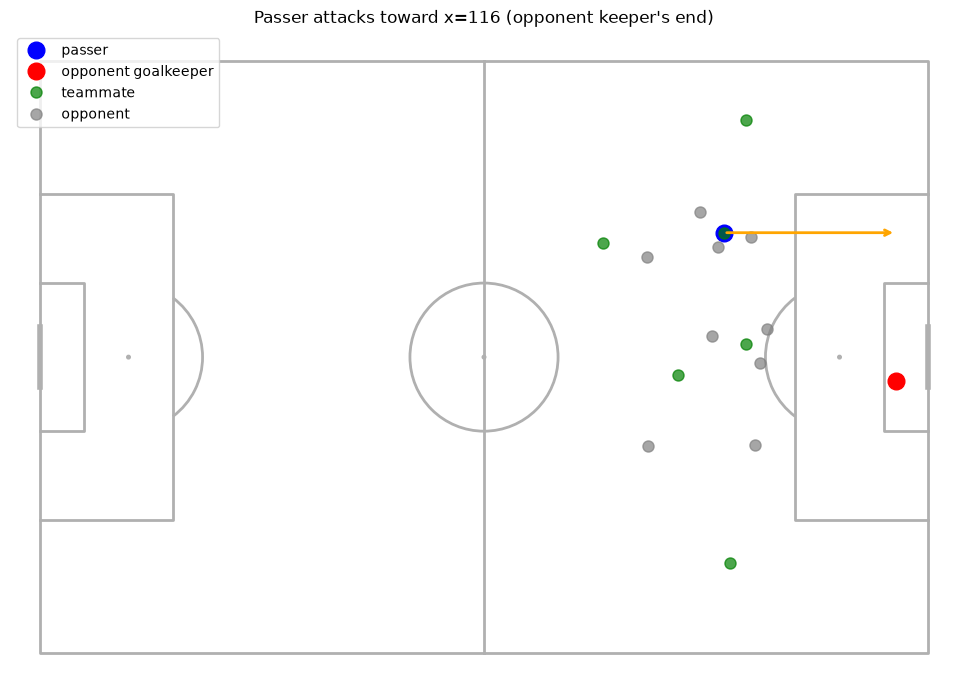

In [5]:
pitch = Pitch(pitch_type='statsbomb')
fig, ax = pitch.draw(figsize=(10, 7))

passer_loc = sample['location']
keeper_loc = opponent_keeper.iloc[0]['location']

# passer
ax.plot(passer_loc[0], passer_loc[1], 'o', color='blue', markersize=12, label='passer')

# opponent goalkeeper
ax.plot(keeper_loc[0], keeper_loc[1], 'o', color='red', markersize=12, label='opponent goalkeeper')

# all other players in the frame, for context
others = frame[
    (frame['id'] == event_id) &
    ~((frame['teammate'] == False) & (frame['keeper'] == True))
]

teammates_plotted = False
opponents_plotted = False

for _, row in others.iterrows():
    loc = row['location']
    if row['teammate']:
        label = 'teammate' if not teammates_plotted else None
        ax.plot(loc[0], loc[1], 'o', color='green', markersize=8, alpha=0.7, label=label)
        teammates_plotted = True
    else:
        label = 'opponent' if not opponents_plotted else None
        ax.plot(loc[0], loc[1], 'o', color='grey', markersize=8, alpha=0.7, label=label)
        opponents_plotted = True

# arrow showing implied attacking direction: passer toward keeper's end
attacking_toward_x = keeper_loc[0]
ax.annotate('', xy=(min(attacking_toward_x, 118), passer_loc[1]), xytext=(passer_loc[0], passer_loc[1]),
            arrowprops=dict(arrowstyle='->', color='orange', lw=2))

ax.legend(loc='upper left')
ax.set_title(f"Passer attacks toward x={attacking_toward_x:.0f} (opponent keeper's end)")
plt.show()

Compute the offside line for this pass

The offside line is defined by the second-deepest defender (opponent), sorted by proximity to their own goal, the goalkeeper included in that ordering, not excluded by default. "Deepest" means closest to the goal line the defending team is protecting, which we now know from the opponent keeper's position: if the keeper sits near x=120, the defending team's goal is at x=120, so "deepest" means highest x.

A candidate teammate is offside if their x-position is beyond both the ball's position and the second-deepest defender's x-position, on the attacking side.

In [6]:
def compute_offside_line(frame_at_event, attacking_toward_x):
    """
    Given all players in a 360 frame and the x-coordinate the attacking team
    is attacking toward, return the offside line x-coordinate: the position
    of the second-deepest defender (goalkeeper included in the sort).
    """
    defenders = frame_at_event[frame_at_event['teammate'] == False].copy()
    if len(defenders) < 2:
        return None  # not enough defenders visible to determine a line

    defenders['x'] = defenders['location'].apply(lambda loc: loc[0])

    # "deepest" = closest to the goal they're defending
    if attacking_toward_x > 60:
        # defending team's goal is at high x -> deepest defender has HIGHEST x
        sorted_defenders = defenders.sort_values('x', ascending=False)
    else:
        # defending team's goal is at low x -> deepest defender has LOWEST x
        sorted_defenders = defenders.sort_values('x', ascending=True)

    second_deepest_x = sorted_defenders.iloc[1]['x']
    return second_deepest_x


def is_offside(candidate_x, ball_x, offside_line_x, attacking_toward_x):
    """
    A candidate is offside if they are beyond BOTH the ball and the
    second-deepest defender, on the attacking side.
    """
    if offside_line_x is None:
        return False  # can't determine, default to not-offside (conservative)

    if attacking_toward_x > 60:
        return candidate_x > ball_x and candidate_x > offside_line_x
    else:
        return candidate_x < ball_x and candidate_x < offside_line_x


# test on this sample pass
offside_line_x = compute_offside_line(frame[frame['id'] == event_id], attacking_toward_x)
print(f"Offside line x-coordinate: {offside_line_x:.2f}")
print(f"Ball (pass start) x-coordinate: {passer_loc[0]:.2f}")

teammates_in_frame = frame[(frame['id'] == event_id) & (frame['teammate'] == True)]
for _, row in teammates_in_frame.iterrows():
    tx = row['location'][0]
    offside = is_offside(tx, passer_loc[0], offside_line_x, attacking_toward_x)
    print(f"  Teammate at x={tx:.2f}: {'OFFSIDE' if offside else 'onside'}")

Offside line x-coordinate: 98.23
Ball (pass start) x-coordinate: 92.40
  Teammate at x=76.00: onside
  Teammate at x=86.22: onside
  Teammate at x=92.40: onside
  Teammate at x=93.26: onside
  Teammate at x=95.40: onside
  Teammate at x=95.42: onside


In [7]:
# scan a handful of passes in this match looking for a genuine offside case
for idx in range(0, 200):
    test_sample = sample_pass_events.iloc[idx]
    test_event_id = test_sample['id']
    test_frame_data = m_frames[m_frames['id'] == test_event_id]

    test_keeper = test_frame_data[(test_frame_data['teammate'] == False) & (test_frame_data['keeper'] == True)]
    if test_keeper.empty:
        continue

    test_attacking_toward_x = test_keeper.iloc[0]['location'][0]
    test_offside_line = compute_offside_line(test_frame_data, test_attacking_toward_x)
    if test_offside_line is None:
        continue

    test_ball_x = test_sample['location'][0]
    test_teammates = test_frame_data[test_frame_data['teammate'] == True]

    for _, row in test_teammates.iterrows():
        tx = row['location'][0]
        if is_offside(tx, test_ball_x, test_offside_line, test_attacking_toward_x):
            print(f"Found offside candidate at pass index {idx}, event_id {test_event_id}")
            print(f"  Candidate x={tx:.2f}, offside line={test_offside_line:.2f}, ball x={test_ball_x:.2f}")
            break

Found offside candidate at pass index 78, event_id dd7c66d5-69c1-48dc-b931-204ba90f0a70
  Candidate x=110.25, offside line=109.80, ball x=106.50
Found offside candidate at pass index 158, event_id a8241a9b-b73e-4f83-8506-8895c29647c1
  Candidate x=112.51, offside line=109.82, ball x=100.20
Found offside candidate at pass index 187, event_id e02750b9-17cb-4509-bfed-0bea551126bf
  Candidate x=104.35, offside line=103.35, ball x=81.00
Found offside candidate at pass index 189, event_id 81c1c2ec-9c0b-4cae-90f8-09c5e0c358d2
  Candidate x=105.33, offside line=104.16, ball x=90.10
Found offside candidate at pass index 190, event_id f3f38929-16fa-412d-950b-096b105dd69f
  Candidate x=99.92, offside line=99.60, ball x=80.40


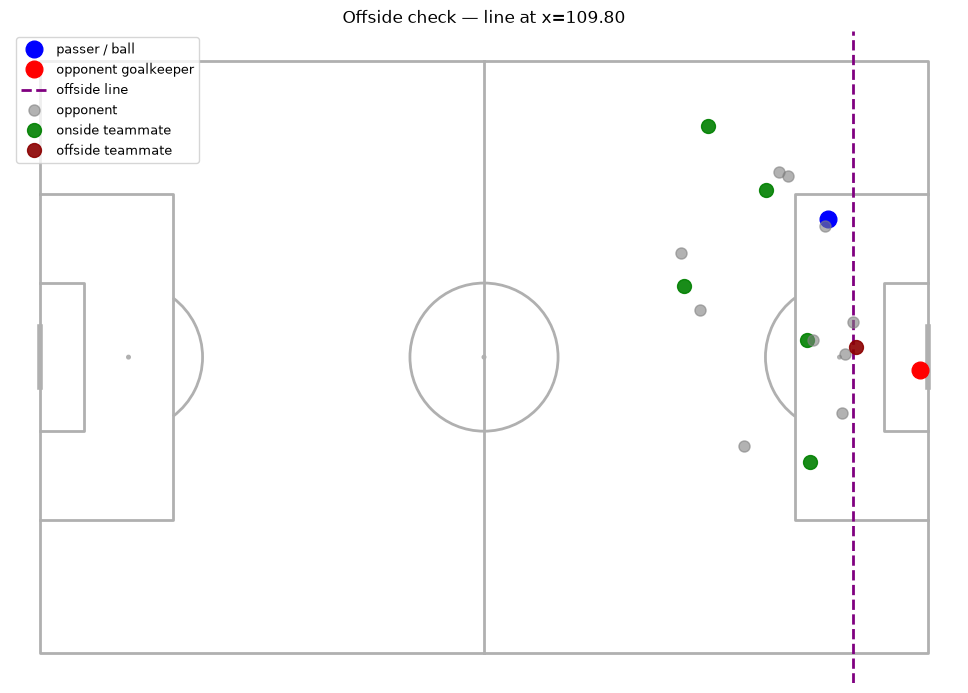

In [8]:
test_event_id = "dd7c66d5-69c1-48dc-b931-204ba90f0a70"
test_sample = sample_pass_events[sample_pass_events['id'] == test_event_id].iloc[0]
test_frame_data = m_frames[m_frames['id'] == test_event_id]

test_keeper = test_frame_data[(test_frame_data['teammate'] == False) & (test_frame_data['keeper'] == True)]
test_attacking_toward_x = test_keeper.iloc[0]['location'][0]
test_offside_line = compute_offside_line(test_frame_data, test_attacking_toward_x)
test_ball_loc = test_sample['location']

pitch = Pitch(pitch_type='statsbomb')
fig, ax = pitch.draw(figsize=(10, 7))

# ball / passer
ax.plot(test_ball_loc[0], test_ball_loc[1], 'o', color='blue', markersize=12, label='passer / ball')

# opponent keeper
ax.plot(test_keeper.iloc[0]['location'][0], test_keeper.iloc[0]['location'][1],
        'o', color='red', markersize=12, label='opponent goalkeeper')

# offside line, drawn vertically across the pitch
ax.axvline(test_offside_line, color='purple', linestyle='--', linewidth=2, label='offside line')

# all other players
teammates_plotted, opponents_plotted = False, False
for _, row in test_frame_data.iterrows():
    if row.get('actor', False):
        continue
    loc = row['location']
    if row['teammate']:
        tx = loc[0]
        is_off = is_offside(tx, test_ball_loc[0], test_offside_line, test_attacking_toward_x)
        color = 'darkred' if is_off else 'green'
        label = ('offside teammate' if is_off else 'onside teammate')
        ax.plot(loc[0], loc[1], 'o', color=color, markersize=10, alpha=0.9,
                label=label if (is_off or not teammates_plotted) else None)
        teammates_plotted = True
    else:
        if row.get('keeper', False):
            continue
        label = 'opponent' if not opponents_plotted else None
        ax.plot(loc[0], loc[1], 'o', color='grey', markersize=8, alpha=0.6, label=label)
        opponents_plotted = True

ax.legend(loc='upper left', fontsize=9)
ax.set_title(f"Offside check — line at x={test_offside_line:.2f}")
plt.show()

In [9]:
from src.offside import classify_offside

# re-run your positive-case example using the packaged version
test_result = classify_offside(test_frame_data, test_ball_loc)
print(test_result[['location', 'attacking_toward_x', 'offside']])

                                      location  attacking_toward_x  offside
5157   [86.98170306169067, 30.330890071052735]           118.92478    False
5159    [90.29616167172878, 8.853739984723603]           118.92478    False
5161   [98.01765786485447, 17.398890401235548]           118.92478    False
5164   [103.57368170361602, 37.71423300958111]           118.92478    False
5165   [104.08121642159668, 54.15448454050586]           118.92478    False
5168               [106.5, 21.399999618530273]           118.92478    False
5172  [110.25204370788717, 38.674589868141815]           118.92478     True
